# 20 — 모델 해석 (최종 제출 submit_38 기준)

**submit_38 = 0.5·rank(submit_21) + 0.5·rank(08-25 라벨 규칙)** (리더보드 0.6707)

- 08-25 라벨 규칙 축은 규칙 자체가 투명하다 (라벨=1 위로, 같은 라벨 안에서는 과거 중앙값 낮은 순).
- 모델 축(submit_21 = 0.35·s4 + 0.35·s3 + 0.30·s15)은 셋 다 HGB + 로지스틱 순위평균이다. 대표로 **s2 구조**(피처 42 = 기본 23 + 08-25 라벨 역추론 8 + 라벨 제약 11)를 다시 학습해 해석한다. s3는 s2에 과거 기준선 보정을, s4는 같은 구조에서 피처 31개를 쓴다.

| 절 | 내용 | 그림 |
|---|---|---|
| 0 | 재현 확인 (제출 파일 s2와 순위상관, 백테스트 점수) | — |
| 1 | 피처 그룹 중요도 (그룹을 섞었을 때 백테스트 PR-AUC 하락폭) | `fig1_group_importance.png` |
| 2 | SHAP 요약 (9/1 테스트 694채널, HGB) | `fig2_shap_summary.png` |
| 3 | submit_38 분해 + 개별 예측 사례 | `fig3_local_example.png` |
| 4 | train vs val 비교 | — |

입력: `10_deflation.ipynb`(데이터·피처·모델 정의를 그대로 실행), `submissions/` 제출 파일, 원본 데이터 / 추가 패키지: `shap`

In [1]:
# ===== 10_deflation.ipynb의 1~6절(데이터 · 피처 · 모델 정의)을 그대로 실행 =====
import json, os, platform, warnings
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')

nb10 = json.load(open('10_deflation.ipynb', encoding='utf-8'))
src = []
for c in nb10['cells']:
    s = ''.join(c['source'])
    if c['cell_type'] == 'markdown' and s.startswith('## 7.'):
        break                                                   # 7절(제출 파일 저장)은 실행하지 않음
    if c['cell_type'] == 'code':
        src.append(s)
src = '\n\n'.join(src)
src = src.replace('from IPython.display import display', 'display = lambda *a, **k: None')   # 10번 출력표 생략
src = src.replace("validate_raw(TR_dl", "(lambda *a: {})(TR_dl")                              # 10번 검증 생략
exec(src)

import shap
F = PAIR + CONS
OUT = f'{SUB}/model_interpretation'
os.makedirs(OUT, exist_ok=True)
print('학습 행:', len(TR_dl), '| 테스트 행:', len(TE_defl), '| 피처 수:', len(F))

# ===== 그림 스타일 =====
plt.rcParams.update({'font.family': {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'NanumGothic'),
                     'axes.unicode_minus': False, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#8C8577', 'xtick.color': '#5A5850', 'ytick.color': '#2D2D28'})
INK, MUTED, GREEN, RED, GRAY = '#2D2D28', '#6B6A60', '#3D6B41', '#9A3F35', '#B8B3A7'
NAME = {'log_past_med': '과거 중앙값', 'c_lb': '08-25 라벨=1 기준선 높이', 'c_ub': '08-25 라벨=0 기준선 높이',
        'log_short_med_rel': '쇼츠 성과(롱폼 대비)', 'like_rate': '좋아요율', 'log_view_std': '조회수 변동성',
        'n_long_28': '최근 28일 롱폼 수', 'comment_rate': '댓글률', 'avg_dur': '평균 영상 길이', 'log_q90': '상위 10% 영상 수준',
        'mom_7': '최근 7일 모멘텀', 'prev_f': '08-25 라벨', 'log_prev_past': '08-25 시점 과거 중앙값'}

학습 행: 5102 | 테스트 행: 694
전주 라벨 임계값 추정 — 테스트 원 값: 1.079 | 디플레이트: 0.37


학습 행: 5102 | 테스트 행: 694 | 피처 수: 42


## 0. 재현 확인

전체 학습쌍으로 다시 학습한 예측이 실제 제출 파일 `submit_10_s2_cons_defl.csv`와 같은지 확인한다 (HGB 시드·실행 환경 차이로 완전히 같지는 않음).

In [2]:
s2_re, _ = predict(TR_dl, TE_defl, F)
s2_sub = pd.read_csv(f'{SUB}/submit_10_s2_cons_defl.csv').set_index('row_id').prediction.loc[TE_defl.row_id].values
print('제출 파일 s2와 순위상관:', round(spearmanr(s2_re, s2_sub)[0], 4))

제출 파일 s2와 순위상관: 0.9939


## 1. 피처 그룹 중요도 (permutation)

백테스트(08-01 ~ 08-05, 평가일 − 4일 이전 기준일로 학습)에서 **피처 그룹 전체를 같은 순서로 섞었을 때** 앙상블 점수의 PR-AUC가 얼마나 떨어지는지 본다.
피처를 하나씩 섞으면 서로 상관이 높은 피처(예: 08-25 라벨 관련 19개)가 중요도를 나눠 가져 과소평가되므로 그룹 단위로 섞는다. 그룹당 10회 반복.

In [3]:
G = {
    '08-25 라벨·역추론': PREVF + CONS,
    '과거 수준': ['log_past_med', 'log_q10', 'log_q90', 'log_view_std', 'n_long_5d', 'log_n_long_5d'],
    '업로드 활동': ['n_long_7', 'n_long_14', 'n_long_28', 'n_short_14', 'short_ratio', 'days_since_long', 'days_since_meas', 'avg_dur'],
    '최근 모멘텀': ['mom_7', 'mom_14', 'mom_old', 'trend_slope', 'log_short_med_rel'],
    '시청자 반응': ['like_rate', 'comment_rate'],
    '게임': ['n_games', 'has_game'],
}
assert sorted(sum(G.values(), [])) == sorted(F)

def fit_backtest(td):
    """평가일 td: (평가 데이터, 앙상블 점수 함수)"""
    te = TR_dl[TR_dl.ref_date == td].reset_index(drop=True)
    tr = TR_dl[TR_dl.ref_date <= (pd.Timestamp(td) - pd.Timedelta(days=4)).strftime('%Y-%m-%d')]
    hs = [hgb(s).fit(tr[F], tr.target) for s in range(5)]
    lr = logreg().fit(tr[F], tr.target)
    score = lambda X: (rank01(np.mean([h.predict_proba(X)[:, 1] for h in hs], axis=0)) + rank01(lr.predict_proba(X)[:, 1])) / 2
    return tr, te, score

rng = np.random.default_rng(0)
rows, BT = [], {}
for td in EVAL_DATES:
    tr, te, score = fit_backtest(td)
    BT[td] = (tr, score)
    base = average_precision_score(te.target_raw, score(te[F]))
    for g, cols in G.items():
        for r in range(10):
            X = te[F].copy()
            X[cols] = X[cols].values[rng.permutation(len(X))]          # 그룹 전체를 같은 순서로 섞음 (그룹 내부 관계 유지)
            rows.append({'평가일': td, '그룹': g, '하락폭': base - average_precision_score(te.target_raw, score(X))})
gp = pd.DataFrame(rows).groupby('그룹')['하락폭'].agg(['mean', 'std']).sort_values('mean', ascending=False)
print(gp.round(4))
print('08-25 라벨 그룹 / 과거 수준 =', round(gp['mean'].iloc[0] / gp.loc['과거 수준', 'mean'], 2), '배')

                mean     std
그룹                          
08-25 라벨·역추론  0.2270  0.0338
과거 수준         0.0847  0.0226
업로드 활동        0.0363  0.0168
최근 모멘텀        0.0263  0.0157
시청자 반응        0.0234  0.0203
게임            0.0009  0.0037
08-25 라벨 그룹 / 과거 수준 = 2.68 배


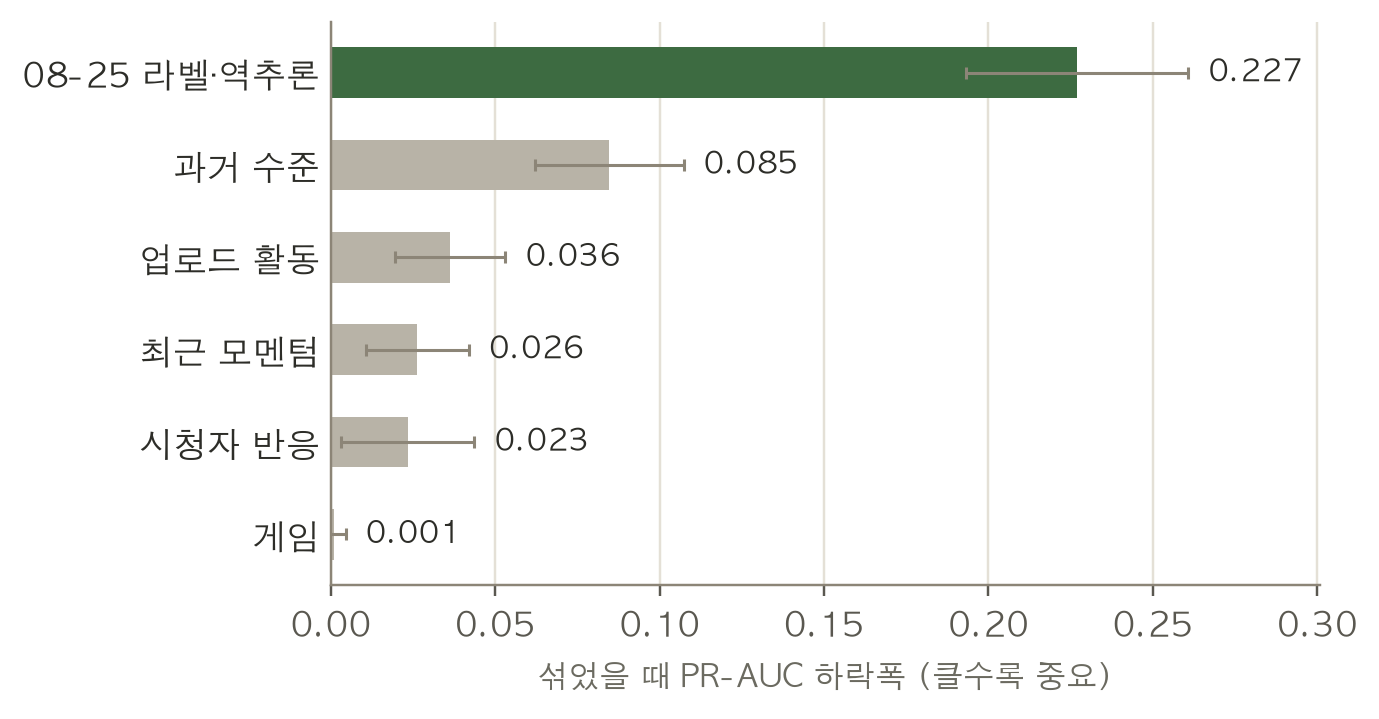

In [4]:
g = gp.iloc[::-1]
fig, ax = plt.subplots(figsize=(6.4, 3.4), dpi=220)
ax.barh(g.index, g['mean'], color=[GREEN if i == gp.index[0] else GRAY for i in g.index], height=0.55,
        xerr=g['std'], error_kw={'ecolor': '#8C8577', 'lw': 1, 'capsize': 2})
for y, (v, s) in enumerate(zip(g['mean'], g['std'])):
    ax.text(v + s + 0.006, y, f'{v:.3f}', va='center', fontsize=10, color=INK)
ax.set_xlabel('섞었을 때 PR-AUC 하락폭 (클수록 중요)', fontsize=10, color=MUTED)
ax.set_xlim(0, g['mean'].max() + g['std'].max() + 0.04); ax.tick_params(axis='y', length=0)
ax.grid(axis='x', color='#E4E0D6', lw=0.8); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(f'{OUT}/fig1_group_importance.png'); plt.show()

## 2. SHAP 요약 (9/1 테스트 예측)

전체 학습쌍으로 학습한 최종 모델이 **실제 9/1 테스트 694채널**을 어떻게 예측했는지 설명한다.
- HGB: `shap.TreeExplainer` (5개 시드 평균, log-odds 단위)
- 로지스틱: 계수 × 표준화 값 = 선형 모델의 정확한 SHAP. 그룹 비중이 HGB와 거의 같아서 그림은 HGB로 대표한다.

In [5]:
hs_all = [hgb(s).fit(TR_dl[F], TR_dl.target) for s in range(5)]
X = TE_defl[F].reset_index(drop=True)
sv = np.mean([np.asarray(shap.TreeExplainer(h).shap_values(X)) for h in hs_all], axis=0)
lr_all = logreg().fit(TR_dl[F], TR_dl.target)
lr_contrib = lr_all.named_steps['sc'].transform(lr_all.named_steps['imp'].transform(X)) * lr_all.named_steps['m'].coef_[0]

imp = pd.DataFrame({'HGB 평균|SHAP|': np.abs(sv).mean(0), 'LR 평균|기여|': np.abs(lr_contrib).mean(0)}, index=F)
print(imp.sort_values('HGB 평균|SHAP|', ascending=False).head(10).round(3))

share = pd.DataFrame({'HGB': [np.abs(sv[:, [F.index(f) for f in c]].sum(1)).mean() for c in G.values()],
                      'LR':  [np.abs(lr_contrib[:, [F.index(f) for f in c]].sum(1)).mean() for c in G.values()]}, index=list(G))
print('\n그룹별 기여 비중'); print((share / share.sum()).round(3))

print('\n방향 (피처 값과 SHAP의 상관, + = 값이 클수록 Rising 쪽)')
for f in imp.sort_values('HGB 평균|SHAP|', ascending=False).index[:8]:
    x = X[f].values.astype(float); ok = ~np.isnan(x)
    print(f'  {f:18s} {np.corrcoef(x[ok], sv[ok, F.index(f)])[0, 1]:+.2f}  (결측 {1 - ok.mean():.0%})')

                   HGB 평균|SHAP|  LR 평균|기여|
log_past_med              0.343      0.734
c_lb                      0.298      0.060
c_ub                      0.231      0.077
log_short_med_rel         0.193      0.146
like_rate                 0.183      0.047
log_view_std              0.167      0.295
n_long_28                 0.153      0.286
comment_rate              0.153      0.062
avg_dur                   0.141      0.084
log_q90                   0.132      0.186

그룹별 기여 비중
                HGB     LR
08-25 라벨·역추론  0.332  0.335
과거 수준         0.234  0.229
업로드 활동        0.136  0.184
최근 모멘텀        0.165  0.202
시청자 반응        0.117  0.030
게임            0.015  0.020

방향 (피처 값과 SHAP의 상관, + = 값이 클수록 Rising 쪽)
  log_past_med       -0.83  (결측 0%)
  c_lb               +0.78  (결측 81%)
  c_ub               +0.77  (결측 23%)
  log_short_med_rel  +0.94  (결측 37%)
  like_rate          -0.20  (결측 2%)
  log_view_std       +0.66  (결측 0%)
  n_long_28          -0.56  (결측 0%)
  comment_rate       +0.06  (결

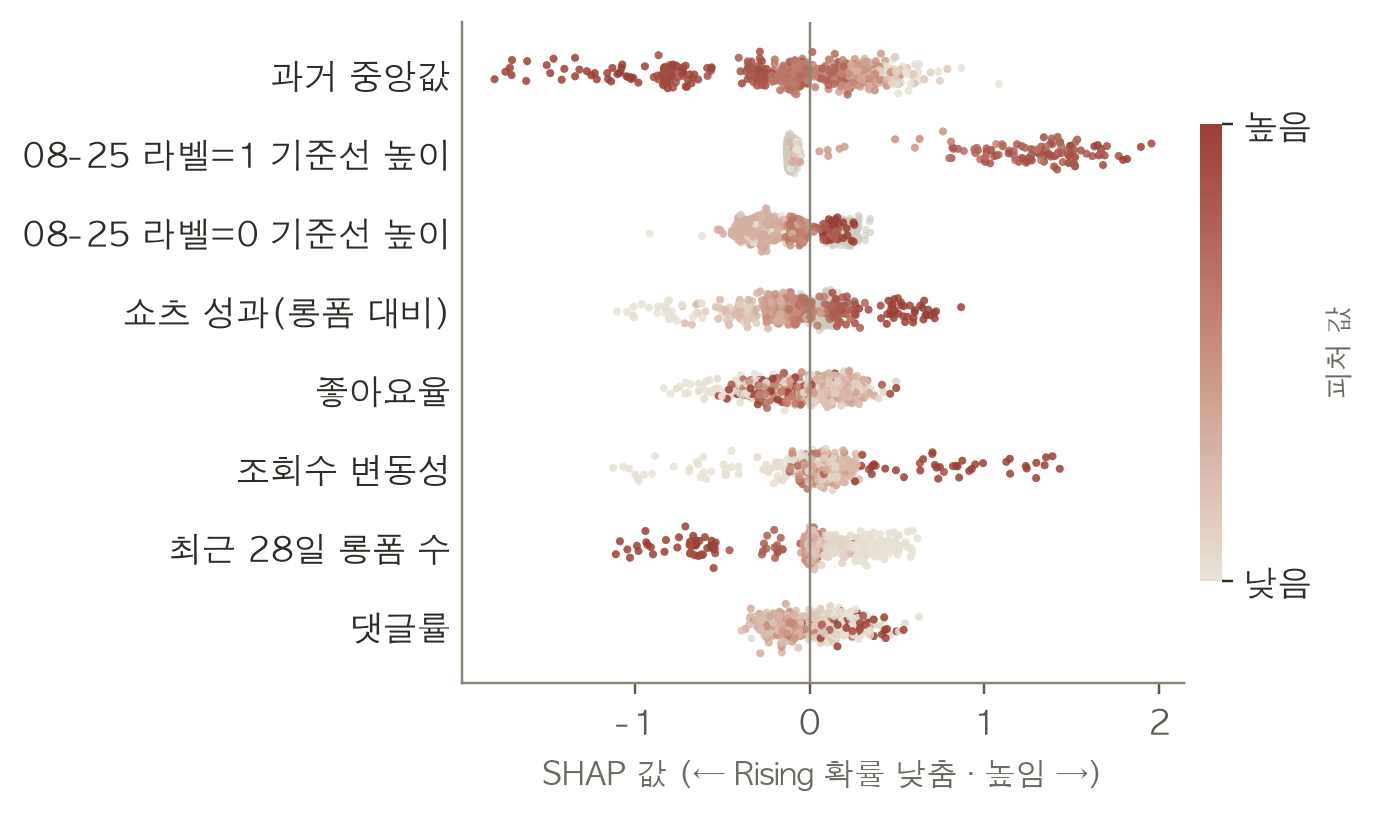

In [6]:
order = imp['HGB 평균|SHAP|'].sort_values(ascending=False).index[:8][::-1]
cmap = LinearSegmentedColormap.from_list('v', ['#E8E2D6', '#C98F7F', RED])
fig, ax = plt.subplots(figsize=(6.4, 3.9), dpi=220)
jr = np.random.default_rng(0)
for y, f in enumerate(order):
    s = sv[:, F.index(f)]; x = X[f].values.astype(float); ok = ~np.isnan(x)
    c = np.full(len(x), np.nan)
    if ok.any():
        lo, hi = np.nanpercentile(x, 5), np.nanpercentile(x, 95)
        c[ok] = np.clip((x[ok] - lo) / (hi - lo + 1e-9), 0, 1)
    jit = jr.normal(0, 0.09, len(s))
    ax.scatter(s[~ok], y + jit[~ok], s=6, color='#CFCAC0', alpha=0.6, lw=0)                  # 회색 = 결측
    ax.scatter(s[ok], y + jit[ok], s=7, c=c[ok], cmap=cmap, vmin=0, vmax=1, alpha=0.85, lw=0)
ax.axvline(0, color='#8C8577', lw=0.8)
ax.set_yticks(range(len(order))); ax.set_yticklabels([NAME.get(f, f) for f in order]); ax.tick_params(axis='y', length=0)
ax.set_xlabel('SHAP 값 (← Rising 확률 낮춤 · 높임 →)', fontsize=10, color=MUTED)
cb = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1)), ax=ax, fraction=0.03, pad=0.02)
cb.set_ticks([0, 1]); cb.set_ticklabels(['낮음', '높음']); cb.set_label('피처 값', fontsize=9, color=MUTED); cb.outline.set_visible(False)
fig.tight_layout(); fig.savefig(f'{OUT}/fig2_shap_summary.png'); plt.show()

## 3. submit_38 분해 + 개별 예측 사례

- 08-25 라벨 그룹(1 / 0 / 없음)만으로 submit_38 순위 변동을 얼마나 설명하는지 (그룹 평균으로 대체했을 때의 R²)
- submit_38 상위 139개(양성 수 ≈ 694 × 0.2)의 08-25 라벨 구성
- 사례: **08-25 라벨 = 0인데 submit_38 상위 139개에 든 채널 중 가장 높은 채널** — 라벨 규칙만으로는 몇 위, 모델(submit_21)은 몇 위였고, 모델이 왜 끌어올렸는지 SHAP으로 본다.

In [7]:
lp = con.sql(f"""SELECT channel_id, MEDIAN(LN(1 + view_5d)) AS lp FROM video_5d_views
                 WHERE is_shorts = 0 AND view_5d IS NOT NULL AND published_at < TIMESTAMP '{D}' GROUP BY 1""").df()
tl = pd.read_csv(f'{RAW}/train_labels.csv'); tl['channel_id'] = tl.row_id.str.rsplit('_', n=1).str[0]
prev825 = tl[tl.row_id.str.endswith(PREV)][['channel_id', 'target']].rename(columns={'target': 'prev'})
m = TE_defl[['row_id', 'channel_id']].reset_index(drop=True).merge(prev825, on='channel_id', how='left').merge(lp, on='channel_id', how='left')
read = lambda f: pd.read_csv(f'{SUB}/{f}').set_index('row_id').prediction.loc[m.row_id].values
m['s38'], m['s21'] = read('submit_38_ens21_prevrule50.csv'), read('submit_21_ens_s4_s3_s15.csv')

prev_f = m.prev.fillna(0.2).values
m['r_rule'] = rank01(prev_f + 1e-3 * rank01(-m.lp))          # 13_prevrule_blend.ipynb의 08-25 라벨 규칙과 동일
m['r38'] = rank01(m.s38)
m['순위_38'] = (-m.s38).rank().astype(int)
m['순위_21'] = (-m.s21).rank().astype(int)
m['순위_규칙'] = (-m.r_rule).rank(method='first').astype(int)

grp = m.prev.map({1.0: '라벨1', 0.0: '라벨0'}).fillna('라벨없음')
gm = m.r38.groupby(grp).transform('mean')
print('08-25 라벨 그룹만으로 설명되는 submit_38 순위 변동 (R²):', round(1 - ((m.r38 - gm) ** 2).sum() / ((m.r38 - m.r38.mean()) ** 2).sum(), 3))
top = m[m.순위_38 <= 139]
print('submit_38 상위 139개 중 08-25 라벨 1 / 0 / 없음:', int((top.prev == 1).sum()), int((top.prev == 0).sum()), int(top.prev.isna().sum()),
      f'(전체 라벨=1 채널 {int((m.prev == 1).sum())}개)')

ex = top[top.prev == 0].sort_values('순위_38').index[0]
print(f'\n사례 채널: submit_38 {m.loc[ex, "순위_38"]}위 | 라벨 규칙만 {m.loc[ex, "순위_규칙"]}위 | 모델(submit_21) {m.loc[ex, "순위_21"]}위')
sx = pd.Series(sv[ex], index=F)
print(sx.reindex(sx.abs().sort_values(ascending=False).index).head(6).round(2))

08-25 라벨 그룹만으로 설명되는 submit_38 순위 변동 (R²): 0.51
submit_38 상위 139개 중 08-25 라벨 1 / 0 / 없음: 127 5 7 (전체 라벨=1 채널 134개)

사례 채널: submit_38 121위 | 라벨 규칙만 164위 | 모델(submit_21) 83위
log_view_std         0.73
log_short_med_rel    0.71
log_past_med         0.63
n_long_28            0.35
log_prev_past        0.30
like_rate           -0.22
dtype: float64


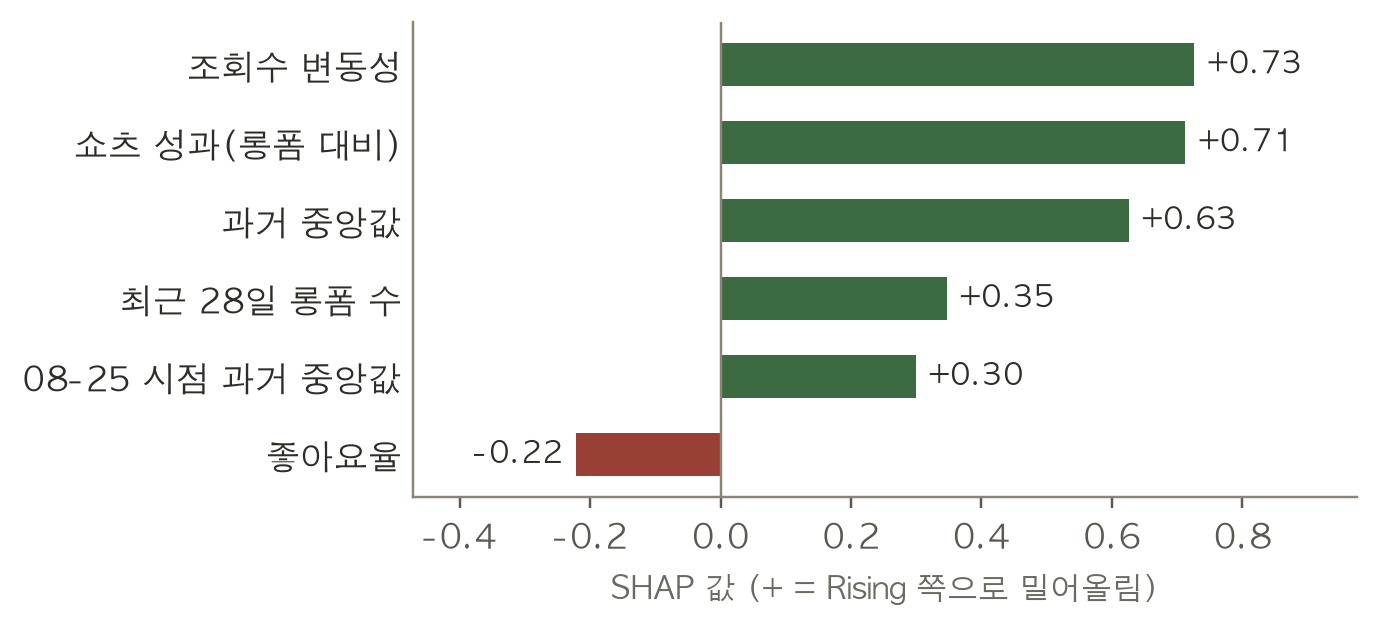

In [8]:
t = sx.reindex(sx.abs().sort_values(ascending=False).index)[:6][::-1]
fig, ax = plt.subplots(figsize=(6.4, 3.0), dpi=220)
ax.barh([NAME.get(f, f) for f in t.index], t.values, color=[GREEN if v > 0 else RED for v in t.values], height=0.55)
for y, v in enumerate(t.values):
    ax.text(v + (0.02 if v > 0 else -0.02), y, f'{v:+.2f}', va='center', ha='left' if v > 0 else 'right', fontsize=10, color=INK)
ax.axvline(0, color='#8C8577', lw=0.8); ax.tick_params(axis='y', length=0)
ax.set_xlim(min(t.min() - 0.25, -0.4), t.max() + 0.25)
ax.set_xlabel('SHAP 값 (+ = Rising 쪽으로 밀어올림)', fontsize=10, color=MUTED)
fig.tight_layout(); fig.savefig(f'{OUT}/fig3_local_example.png'); plt.show()

## 4. train vs val

백테스트 평가일마다: train = 학습에 쓴 기준일별 PR-AUC 평균(기준일 안에서 상위 20%를 맞히는 문제이므로 날짜별 계산), val = 평가일 PR-AUC.

In [9]:
tv = []
for td in EVAL_DATES:
    tr, score = BT[td]
    te = TR_dl[TR_dl.ref_date == td]
    tv.append({'평가일': td[5:],
               'train': np.mean([average_precision_score(g.target_raw, score(g[F])) for _, g in tr.groupby('ref_date')]),
               'val': average_precision_score(te.target_raw, score(te[F]))})
tv = pd.DataFrame(tv).set_index('평가일'); tv.loc['평균'] = tv.mean()
print(tv.round(3))

       train    val
평가일                
08-01  0.785  0.575
08-02  0.779  0.592
08-03  0.763  0.566
08-04  0.764  0.585
08-05  0.755  0.578
평균     0.769  0.579


## 5. 정리 (2026-10 실행 결과)

- **피처 그룹 중요도**: 08-25 라벨·역추론 0.227 ≫ 과거 수준 0.085 (약 2.7배) > 업로드 활동 0.036 > 최근 모멘텀 0.026 > 시청자 반응 0.023 > 게임 0.001
- **SHAP (9/1 테스트)**: 과거 중앙값↑ → Rising↓ (평균회귀) · 08-25 라벨=1 기준선↑ → Rising↑ (역추론) · 변동성·쇼츠 성과↑ → Rising↑ · 최근 28일 롱폼 수↑ → Rising↓. 그룹 비중은 08-25 라벨 약 33%, 과거 수준 약 23% (HGB·LR 거의 동일)
- **submit_38 분해**: 08-25 라벨 그룹만으로 순위 변동의 51% 설명, 상위 139개 중 127개가 라벨=1
- **사례**: 라벨=0인데 121위 — 라벨 규칙만 164위, 모델 83위. 조회수 변동성·쇼츠 성과·낮은 과거 중앙값이 끌어올림 → 라벨 규칙이 놓친 채널을 모델이 보완
- **train vs val**: 0.77 vs 0.58 — 차이가 있어 트리를 얕게(깊이 3) 고정, val은 5개 기준일 모두 0.57 ~ 0.59로 안정적